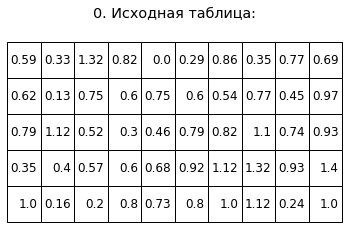

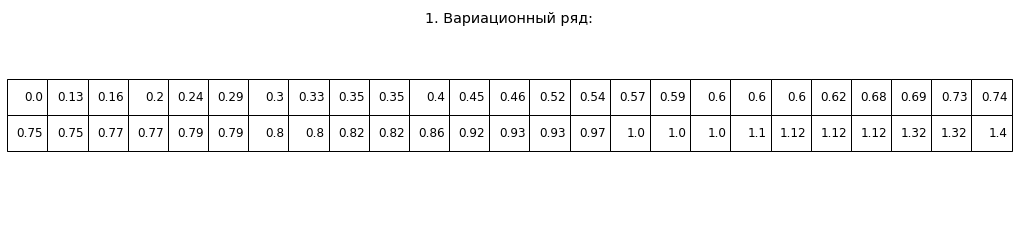

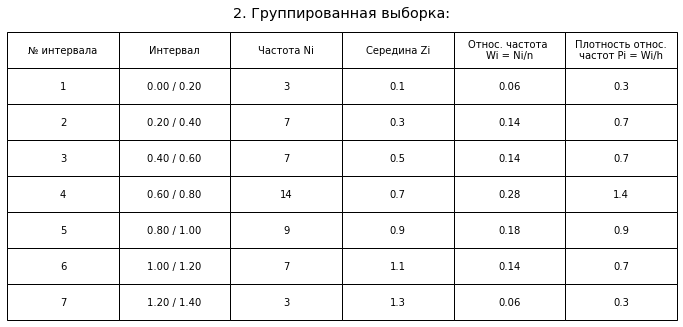

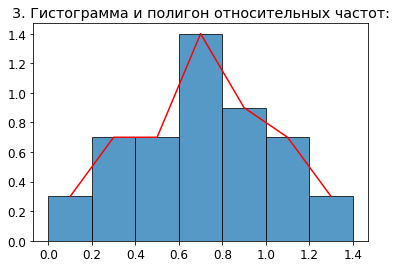

4. Математическое ожидание и среднеквадратическое отклонение:

Математическое ожидание =  0.708
Дисперсия =  0.103
Среднеквадратическое отклонение =  0.321

5. Доверительные интервалы для математического ожидания с доверительными вероятностями 0,95 и 0,99:

Для доверительной вероятность = 0.95 Имеем :
t1 = 2.01 
d1 = 0.091
Для доверительной вероятность = 0.99 Имеем :
t2 = 2.68 
d2 = 0.122
Итого, имеем 2 доверительных интервала для соответсвующих значений:

Интервал №1 = ( 0.617 ; 0.799 )
Интервал №2 = ( 0.586 ; 0.83 )


6. Проанализировав гистограмму и полигон частот, делаем вывод, что мы имеем дело с Нормальным законом распределения


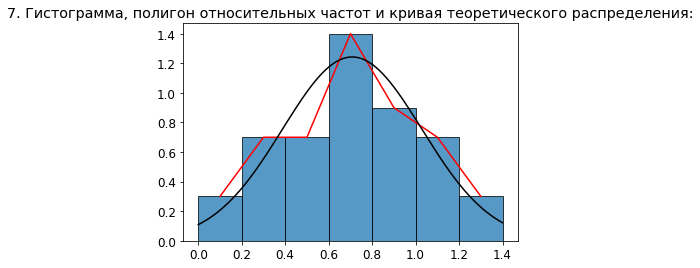

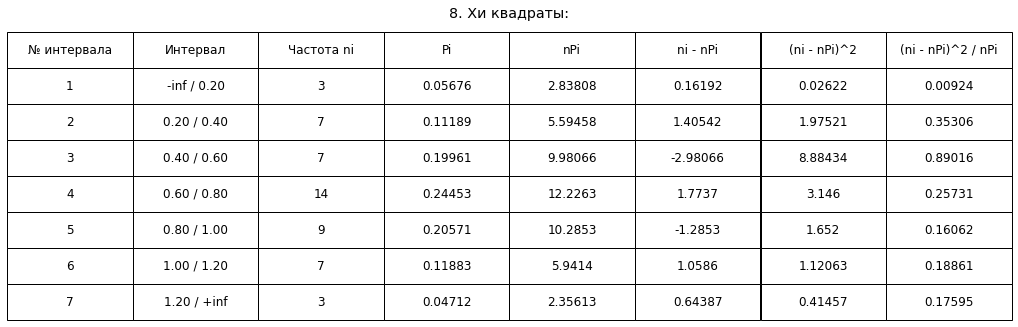

Степени свободы =  2
Хи критическое =  9.21034037197618
Хи наблюдаемое =  1.9487135917732548
Т.к. Хи критическое < Хи наблюдаемого, принимаем гипотезу


In [ ]:
# import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import groupby
import scipy
plt.rcParams.update({'font.size': 12})
viborka = [0.59, 0.33, 1.32, 0.82, 0.00, 0.29, 0.86, 0.35, 0.77, 0.69, 0.62, 0.13, 0.75, 0.60, 0.75, 0.60, 0.54, 0.77, 0.45, 0.97, 0.79, 1.12, 0.52, 0.30, 0.46, 0.79, 0.82, 1.1, 0.74, 0.93, 0.35, 0.40, 0.57, 0.60, 0.68, 0.92, 1.12, 1.32, 0.93, 1.4, 1.00, 0.16, 0.20, 0.80, 0.73, 0.80, 1.00, 1.12, 0.24, 1.0]
#Вычисляем основные значения
n = len(viborka)  #Количество элементов
Xmin = min(viborka)
Xmax = max(viborka)
k = round(math.sqrt(n)) #Вычисляем количество интервалов
R = Xmax - Xmin
h = round(R / k, 2)     #Вычисляем шаг интервалов




# 0) Отображение исходной таблицы

data = np.array(viborka).reshape(n//10, 10)

fig, ax = plt.subplots()
ax.axis('off')
table = ax.table(cellText=data, loc='center')
table.scale (1,3)
ax.set_title('0. Исходная таблица:')

plt.show()

# 1) Отображение вариационного ряда таблицы
viborka.sort()

data = np.array(viborka).reshape(n//25, 25)
fig, ax = plt.subplots()
ax.axis('off')
table = ax.table(cellText=data, loc='center')
table.scale (3,3)
ax.set_title('1. Вариационный ряд:', y = 0.9)

plt.show()





# 2) Группированная выборка
table_data = []
for i in range(k):
    row = []
    # В первый столбец записываем номер интервала
    row.append(i+1)
    # Во второй столбец - интервал
    left = round(Xmin + abs(h*i),1)
    right = round(Xmin + abs(h*(i+1)),1)
    row.append(f"{left:.2f} / {right:.2f}")
    # В третий столбец вписываем количество чисел, попавших в интервал
    count = len([x for x in viborka if left <= x < right])
    if((i == k -1) and (Xmax == right)):
        count+=viborka.count(right)
    Wi = round(count / n, 2)
    row.append(count)                   #Количество в интервале
    row.append(round((right+left)/2,2)) #среднее значение 
    row.append(round(Wi,3))             #Относ. частоты
    row.append(round(Wi/h,3))           #Плотность относ. частот
    table_data.append(row)

# Создаем таблицу
fig, ax = plt.subplots()
ax.axis('off')
ax.set_title('2. Группированная выборка:', y = 1.2)
table = ax.table(cellText=table_data, cellLoc='center', loc='center', colLabels=['№ интервала', 
                                                                                 'Интервал', 
                                                                                 'Частота Ni', 
                                                                                 'Середина Zi',
                                                                                'Относ. частота \nWi = Ni/n',
                                                                                'Плотность относ.\nчастот Pi = Wi/h'])
table.scale (2,3)
plt.show()




# 3) Гистограмма и полигон относительных частот 
density = [row[-1] for row in table_data]   #Получаем все плотности относительных частот (по оси Y)
intervals = [row[1] for row in table_data]  #Получаем все интервалы как список строк     (по оси X)
sred_x = [row[3] for row in table_data]      #Получаем все средние значения               (по оси X)
new_xx = [float(intervals[i].split('/')[0]) for i in range (0,len(intervals))] #Получаем интервалы в виде списка чисел        

# Создаем гистограмму
fig, ax = plt.subplots()
new_xx.append(Xmax) #чтобы вошел последнее значение интервала
ax.bar(new_xx[0:-1], density, h, align='edge', alpha=0.75, edgecolor='black')

# Добавляем метки осей и заголовок
ax.set_xticks(new_xx)
ax.set_title('3. Гистограмма и полигон относительных частот:')

# Отображаем полигон и гистограмму
plt.plot(sred_x, density, color = 'r') #создали график
plt.show()




# 4. Ищем мат. ожидание и среднеквадратическое отклонение

print("4. Математическое ожидание и среднеквадратическое отклонение:\n")
Mx = 0 #Мат Ожидание
Dx = 0 #Дисперсия
S = 0 #Среднеквадратичное отклонение

for i in range (0,k):
    Mx += table_data[i][2] * table_data[i][3]
Mx =round(Mx / n,3)

for i in range (0,k):
    Dx += table_data[i][2] * table_data[i][3] **2
Dx = round(n/(n-1)*(Dx/50 - Mx ** 2),3)

S = round(math.sqrt(Dx),3)

#Выводим все эти данные
print("Математическое ожидание = " , Mx)
print("Дисперсия = " , Dx)
print("Среднеквадратическое отклонение = " , S)




# 5. Доверительные интервалы для матема- тического ожидания с доверительными вероятностями 0,95 и 0,99.

print("\n5. Доверительные интервалы для математического ожидания с доверительными вероятностями 0,95 и 0,99:\n")
t1 = 2.01
t2 = 2.68
d1 = round(t1*S/math.sqrt(n), 3)
d2 = round(t2*S/math.sqrt(n), 3)


print("Для доверительной вероятность = 0.95 Имеем :\nt1 =",t1, "\nd1 =",d1)
print("Для доверительной вероятность = 0.99 Имеем :\nt2 =",t2, "\nd2 =",d2)
print("Итого, имеем 2 доверительных интервала для соответсвующих значений:\n")

print("Интервал №1 = (" , round(Mx-d1,3),";", round(Mx+d1,3),")")
print("Интервал №2 = (" , round(Mx-d2,3),";", round(Mx+d2,3),")")



# 6. Анализируем гистограмму и делаем вывод

print("\n\n6. Проанализировав гистограмму и полигон частот, делаем вывод, что мы имеем дело с Нормальным законом распределения")



# 7. Строим гистограмму, полигон частот и кривую теоретического распределения

# Создаем гистограмму
fig, ax = plt.subplots()
ax.bar(new_xx[0:-1], density, h, align='edge', alpha=0.75, edgecolor='black')

# Добавляем метки осей и заголовок
ax.set_xticks(new_xx)
ax.set_title('7. Гистограмма, полигон относительных частот и кривая теоретического распределения:')

# Отображаем полигон и гистограмму
plt.plot(sred_x, density, color = 'r') #создали полигон частот 

#Отображаем теоретическое отклонение со средним = Mx и стандартным отклонением = S
x = np.arange (Xmin, Xmax, 0.001)
plt.plot (x, norm. pdf (x, Mx, S), color = 'black')

plt.show()
print("\n\n")


# 8. Проверяем гипотезу о том, что выборка имеет выбранное теоретическое распределение. Уровень значимости = 0,01
a = 0.01
lap_minus_inf = -0.5
lap_plus_inf = 0.5


# Заполняем таблицу Хи квадратов
table_data2 = []
a = 0.01 #Уровень значимости
Xkr = 0
Xnab = 0
step_svobod = 0

for i in range(k):
    row = []
    # В первый столбец записываем номер интервала
    # Во второй столбец - интервал
    left = round(Xmin + abs(h*i),1)
    right = round(Xmin + abs(h*(i+1)),1)
    # В третий столбец вписываем количество чисел, попавших в интервал
    count = len([x for x in viborka if left <= x < right])
    if((i == k -1) and (Xmax == right)):
        count+=viborka.count(right)
    row.append(i+1)                          # Добавили номер
    if(i == 0):
        row.append(f"-inf / {right:.2f}")  # Добавили интервал
    elif(i == k-1):
        row.append(f"{left:.2f} / +inf")  # Добавили интервал    
    else:
        row.append(f"{left:.2f} / {right:.2f}")  # Добавили интервал
        
    
    row.append(count)                        #Количество в интервале
    #Считаем вероятность попадания в интервал Pi
    pi = 0.0
    if( i == 0):
        pi = Laplas((right-Mx)/S) - lap_minus_inf
    else:
        pi = Laplas((right - Mx)/S) - Laplas((left - Mx)/S)
    row.append(round(pi,5))                           #Добавили Pi
    row.append(round(pi * n,5))                       #Добавили n*Pi
    row.append(round(count - pi * n,5))               #Добавили ni - npi
    row.append(round((count - pi * n)**2,5))          #(ni - npi)^2
    row.append(round(((count - pi * n)**2) / (n*pi),5)) #(ni - npi)^2 / npi
    
    
    
    
    table_data2.append(row)

    

# Создаем таблицу
fig, ax = plt.subplots()
ax.axis('off')
ax.set_title('8. Хи квадраты:', y = 1.2)
table = ax.table(cellText=table_data2, cellLoc='center', loc='center', colLabels=['№ интервала', 
                                                                                 'Интервал', 
                                                                                 'Частота ni',
                                                                                 'Pi',
                                                                                 'nPi',
                                                                                 'ni - nPi',
                                                                                 '(ni - nPi)^2',
                                                                                 '(ni - nPi)^2 / nPi'])
table.scale (3,3)
plt.show()

#Объединяем, если есть ni<=5:

if(table_data2[0][2] <=5 or table_data2[1][2] <=5):
    table_data2[1][2] += table_data2[0][2]#для частот
    table_data2[1][3] += table_data2[0][3] #pi
    table_data2[1][4] += table_data2[0][4] #npi
    table_data2[1][5] = table_data2[1][2] - table_data2[1][4] #ni-npi
    table_data2[1][6] = table_data2[1][5] ** 2 # (ni-npi) ^ 2
    table_data2[1][7] = table_data2[1][6] / table_data2[1][4] # ((ni-npi) ^ 2) / npi
    
if(table_data2[6][2] <=5 or table_data2[5][2] <=5):
    table_data2[5][2] += table_data2[6][2]#для частот
    table_data2[5][3] += table_data2[6][3] #pi
    table_data2[5][4] += table_data2[6][4] #npi
    table_data2[5][5] = table_data2[5][2] - table_data2[5][4] #ni-npi
    table_data2[5][6] = table_data2[5][5] ** 2 # (ni-npi) ^ 2
    table_data2[5][7] = table_data2[5][6] / table_data2[5][4] # ((ni-npi) ^ 2) / npi

if( table_data2[0][2] <=5 or table_data2[1][2] <=5 or table_data2[6][2] <=5 or table_data2[5][2] <=5):
    for i in range(1,6):
        Xnab+=table_data2[i][7]
    step_svobod = k-2
else:
    for i in range(0,7):
        Xnab+=table_data2[i][7]
    step_svobod = k

step_svobod -=3
print("Степени свободы = ",step_svobod)
Xkr = scipy.stats.chi2.ppf(1-a, step_svobod)
print("Хи критическое = ",Xkr)
print("Хи наблюдаемое = ", Xnab)

if(Xnab < Xkr):
    print("Т.к. Хи критическое > Хи наблюдаемого, принимаем гипотезу")
else:
    print("Т.к. Хи критическое < Хи наблюдаемого, отвергаем гипотезу")

def Laplas(x):
    return scipy.stats.norm.cdf(x) - 0.5